# Code for Generating Visuals for Fractal Generation and Computing Speedup.

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pandata_seq = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/fractal_runs/sequential_run_range_1500.csv")

pandata_2_cpu = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/cpu_npts_1500_c2.csv")
pandata_2_cpu["n_cores"] = [2]* len(pandata_2_cpu)

pandata_4_cpu = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/cpu_npts_1500_c4.csv")
pandata_4_cpu["n_cores"] = [4]* len(pandata_4_cpu)

pandata_8_cpu = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/cpu_npts_1500_c8.csv")
pandata_8_cpu["n_cores"] = [8]* len(pandata_8_cpu)

pandata_16_cpu = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/cpu_npts_1500_c16.csv")
pandata_16_cpu["n_cores"] = [16]* len(pandata_16_cpu)

pandata_32_cpu = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/cpu_npts_1500_c32.csv")
pandata_32_cpu["n_cores"] = [32]* len(pandata_16_cpu)


In [3]:
def return_speedup(pd_seq, pd_cores):
    timing_seq = pd_seq["time"].to_numpy()
    timing_cores = pd_cores["time"].to_numpy()
    return timing_seq/timing_cores
    

In [4]:
timing_cores_q2 = return_speedup(pandata_seq, pandata_2_cpu)
timing_cores_q4 = return_speedup(pandata_seq, pandata_4_cpu)
timing_cores_q8 = return_speedup(pandata_seq, pandata_8_cpu)
timing_cores_q16 = return_speedup(pandata_seq, pandata_16_cpu)
timing_cores_q32 = return_speedup(pandata_seq, pandata_16_cpu)

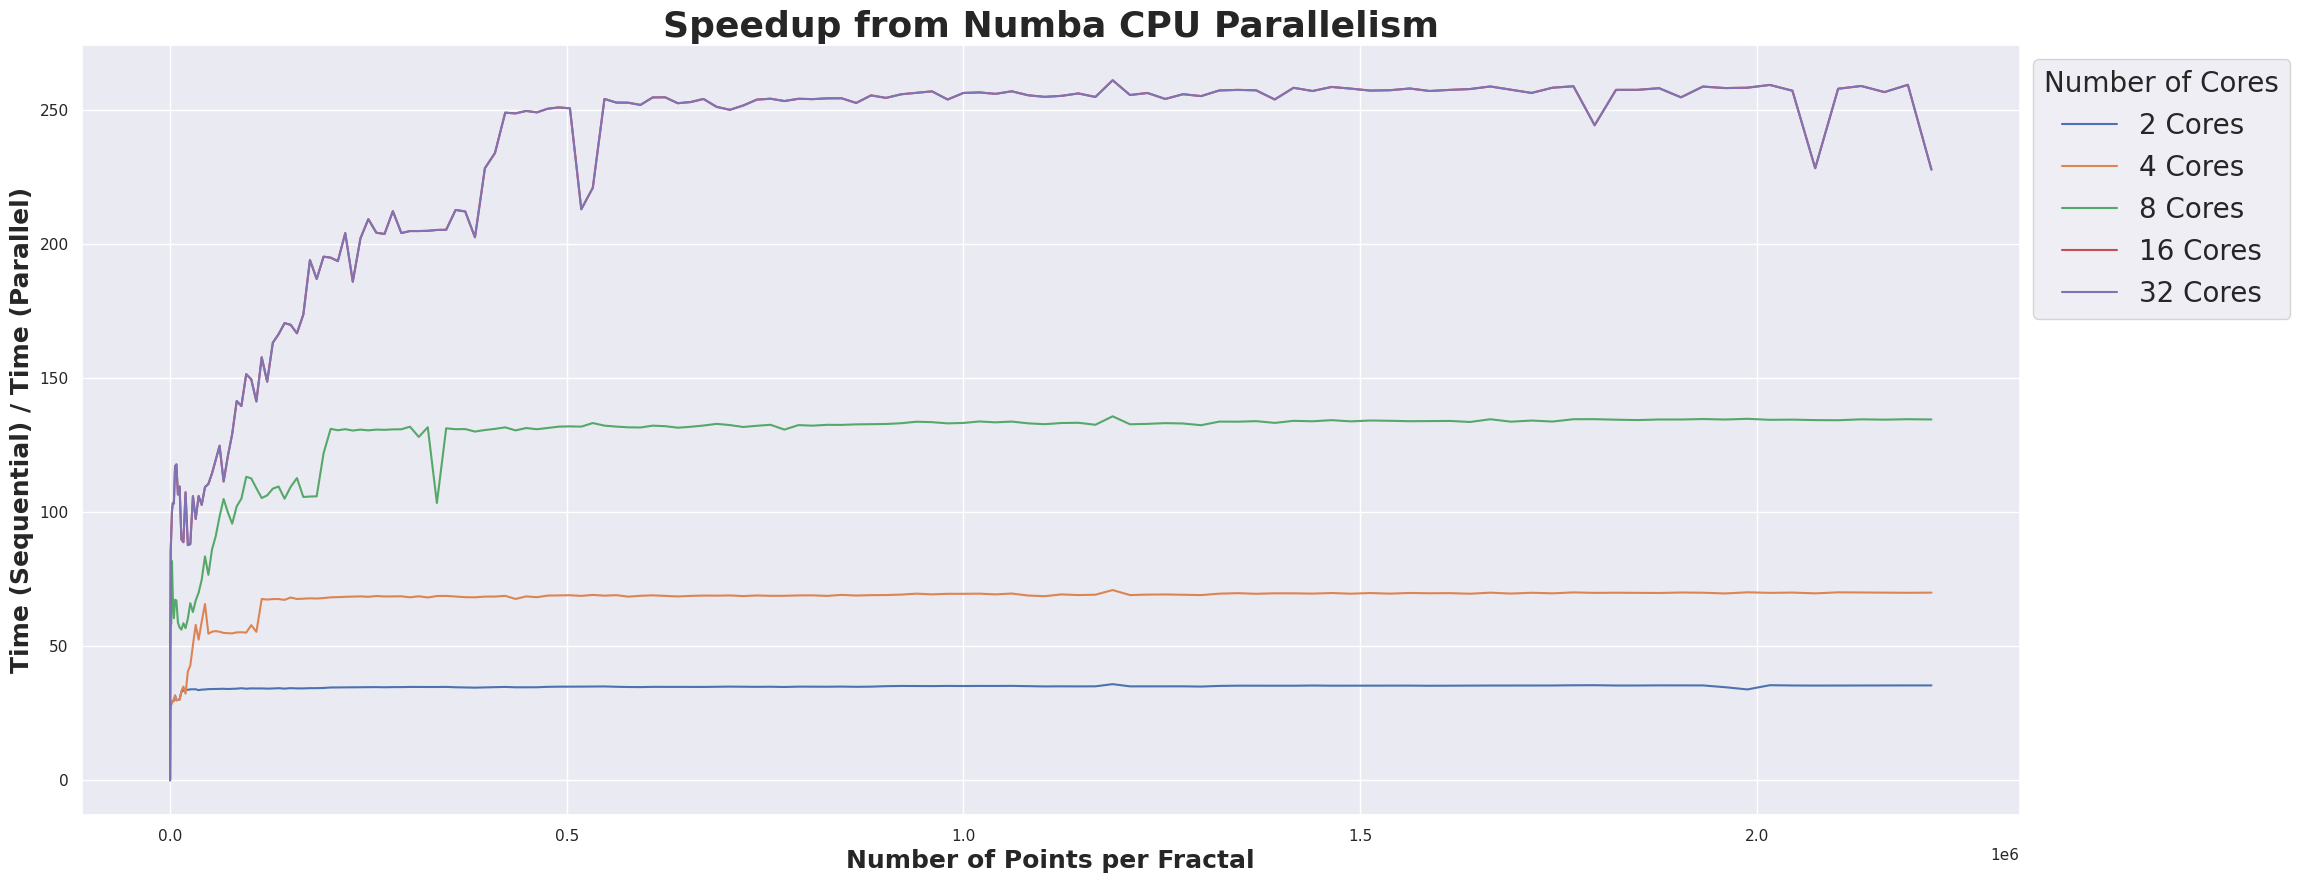

In [5]:
sns.set_theme()
fig, ax = plt.subplots(figsize = (25, 10))

sns.lineplot(ax = ax, x = pandata_seq["n_pts"]**2, y = timing_cores_q2, label = "2 Cores")
sns.lineplot(ax = ax, x = pandata_seq["n_pts"]**2, y = timing_cores_q4, label = "4 Cores")
sns.lineplot(ax = ax, x = pandata_seq["n_pts"]**2, y = timing_cores_q8, label = "8 Cores")
sns.lineplot(ax = ax, x = pandata_seq["n_pts"]**2, y = timing_cores_q16, label = "16 Cores")
sns.lineplot(ax = ax, x = pandata_seq["n_pts"]**2, y = timing_cores_q32, label = "32 Cores")

#plt.yscale("log")
#plt.xscale("log")

plt.ylabel("Time (Sequential) / Time (Parallel)", weight = "bold", size = 18)
plt.xlabel("Number of Points per Fractal", weight = "bold", size = 18)
plt.title("Speedup from Numba CPU Parallelism", weight = "bold", size = 26)
plt.legend(fontsize = 20, title = "Number of Cores", title_fontsize=20, bbox_to_anchor=(1, 1))

In [6]:
pandata_seq = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/fractal_runs/sequential_run_range_1500.csv")
pandata_seq_gpu = pandata_seq

pandata_16_gpu = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/fractal_runs/gpu_global_run_normal_gpu.csv")
pandata_16_gpu["block_dim"] = [16]* len(pandata_16_gpu)


In [7]:
timing_gpu_16 = return_speedup(pandata_seq_gpu, pandata_16_gpu)*1000
timing_cores_32 = return_speedup(pandata_seq_gpu, pandata_16_gpu)*1000

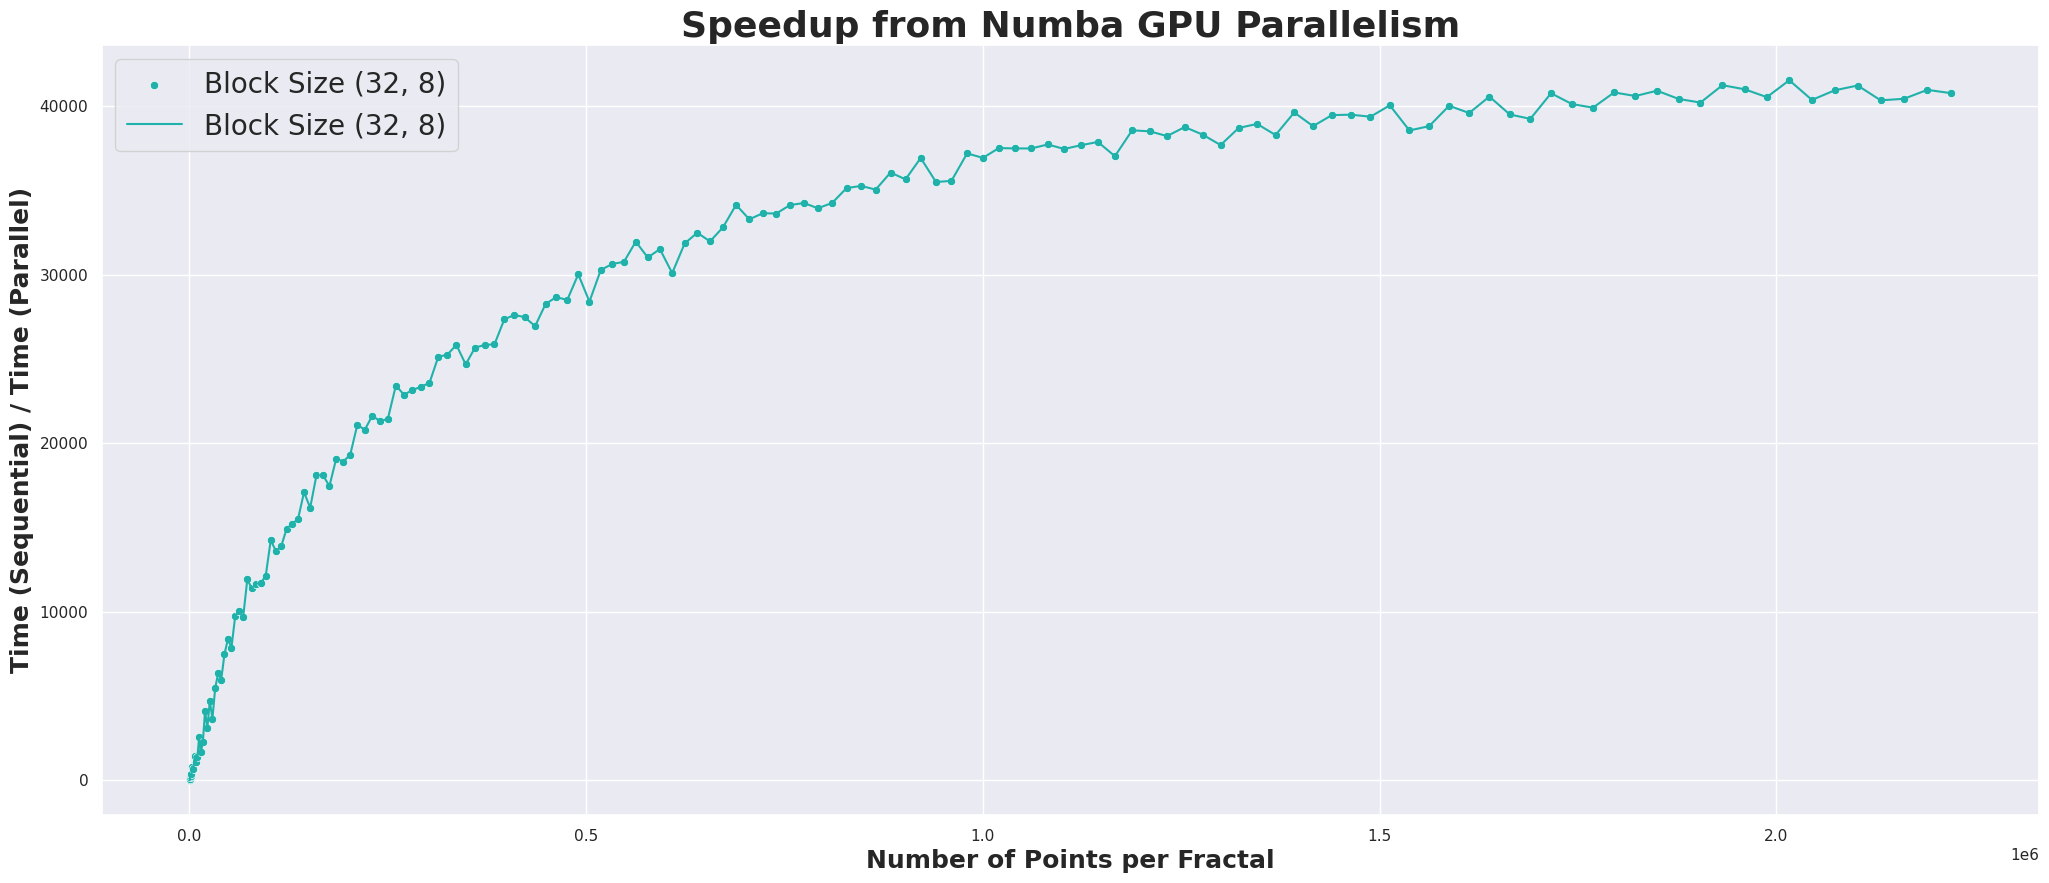

In [8]:
sns.set_theme()
fig, ax = plt.subplots(figsize = (25, 10))

sns.scatterplot(ax = ax, x = pandata_seq_gpu["n_pts"]**2, y = timing_gpu_16, label = "Block Size (32, 8)", color = "lightseagreen")
sns.lineplot(ax = ax, x = pandata_seq_gpu["n_pts"]**2, y = timing_gpu_16, label = "Block Size (32, 8)", color = "lightseagreen")

#plt.yscale("log")
#plt.xscale("log")

plt.ylabel("Time (Sequential) / Time (Parallel)", weight = "bold", size = 18)
plt.xlabel("Number of Points per Fractal", weight = "bold", size = 18)
plt.title("Speedup from Numba GPU Parallelism", weight = "bold", size = 26)
plt.legend(fontsize = 20)

In [9]:
gpu_large_run = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/fractal_runs/gpu_global_run_normal_gpu_100k.csv")